# Loading our libraries

In [1]:
import pandas as pd # import pandas library as pd
import numpy as np # import numpy library as np

import matplotlib.pyplot as plt # importing pyplot package from the matplot lib
import seaborn as sns # importing seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Loading the dataset

The dataset for this example is derived from a self-assessment conducted with 50 youths at baseline who were involved in a lifeskills project. These youths assessed themselves for interpersonal skills and decision-making skills, assigning scores ranging from 0 to 100 for each category. The project wants to determine the optimal number of clusters to categorize the youths based on their self-assessment scores. This categorization will enable the project to provide tailored project activities and follow-up support to each specific group. As the project officer, you have decided to employ K-means clustering as a tool to assist you in grouping the beneficiaries.

In [3]:
data = pd.read_csv("Data.csv")

In [4]:
data.head()

,Beneficiary_ID,Interpersonal skills,Decision making skills
0,1,64,69
1,2,50,5
2,3,2,1
3,4,29,37
4,5,73,78


#### Dropping missing values (if any)

In [5]:
# Removing all rows that contain at least one missing value.

data.dropna(inplace=True)

In [6]:
# Checking the summary statistics

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Beneficiary_ID,50.0,25.50,14.577380,1.0,13.25,25.5,37.75,50.0
Interpersonal skills,50.0,39.52,32.120462,1.0,9.50,35.5,72.75,94.0
Decision making skills,50.0,36.92,28.357657,1.0,12.75,36.5,50.75,92.0


# Transform the Data

In [7]:
#creating standard normal variables
data[['Interpersonal skills_T', 'Decision making skills_T']]=StandardScaler().fit_transform(data[['Interpersonal skills', 'Decision making skills']])

In [8]:
data.head()

,Beneficiary_ID,Interpersonal skills,Decision making skills,Interpersonal skills_T,Decision making skills_T
0,1,64,69,0.769869,1.142749
1,2,50,5,0.329584,-1.137050
2,3,2,1,-1.179962,-1.279537
3,4,29,37,-0.330842,0.002850
4,5,73,78,1.052908,1.463346


# Identifying the optimal number of clusters

#### Identifying Optimum Number of Clusters

In [9]:
# Create a function to work out optimum number of clusters

import os
import warnings

def optimise_k_means(data, max_k):
    
     # Initialize empty lists to store the number of clusters and corresponding inertias   
    clusters = []
    inertias = []

     # Set OMP_NUM_THREADS environment variable to 1 to avoid the warning related to Intel MKL   
    os.environ['OMP_NUM_THREADS'] = '1'
    # Ignore the UserWarning specifically related to scikit-learn
    warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

    for k in range(1, max_k): # Loop from 1 to max_k (exclusive)
        
        kmeans = KMeans(n_clusters=k, n_init=10)  # Initialize the KMeans model with k clusters and n_init=10 (number of times the algorithm will run)
        kmeans.fit(data)  # Fit the KMeans model to the provided data
        clusters.append(k)  # Append the current value of k to the clusters list
        inertias.append(kmeans.inertia_)  # Append the inertia (sum of squared distances of samples to their closest cluster center) to the inertias list
       
        
    plt.figure(figsize=(10, 5)) # Create a figure with a specific size
    plt.plot(clusters, inertias, marker='o', linestyle='-') # Plot the number of clusters on the x-axis and the corresponding inertias on the y-axis
    
    # Set labels for the x-axis, y-axis, and the title of the plot
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.title('Optimal Number of Clusters')
    
     # Display the plot
    plt.show()

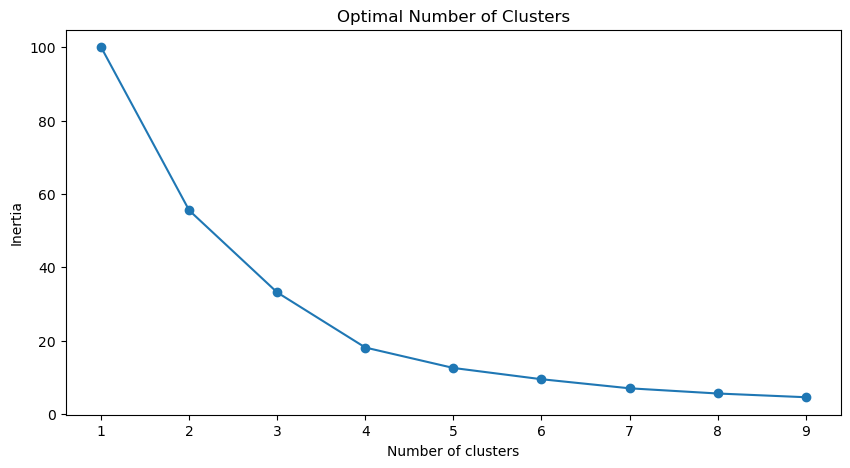

In [10]:
optimise_k_means(data[['Interpersonal skills_T', 'Decision making skills_T']], 10)

The slope of the curve becomes gentle after the 4th cluster (meaning that after that point adding more clusters doesnt reduce the distance between the new cluster centers to their points), and so we decide to choose 4 as the clusters.

# Applying K-Means Clustering

In [11]:
kmeans = KMeans(n_clusters=4, n_init=10) # Initialize the KMeans model with 4 clusters and n_init=10 (the algorithm will run 10 times)
kmeans.fit(data[['Interpersonal skills_T', 'Decision making skills_T']])
data['groups'] = kmeans.labels_

In [12]:
data.head()

,Beneficiary_ID,Interpersonal skills,Decision making skills,Interpersonal skills_T,Decision making skills_T,groups
0,1,64,69,0.769869,1.142749,1
1,2,50,5,0.329584,-1.137050,2
2,3,2,1,-1.179962,-1.279537,3
3,4,29,37,-0.330842,0.002850,0
4,5,73,78,1.052908,1.463346,1


In [13]:
# we can export our data to excel to view all the rows and the groups

data.to_excel('data.xlsx', index=False)

# Plotting the Results

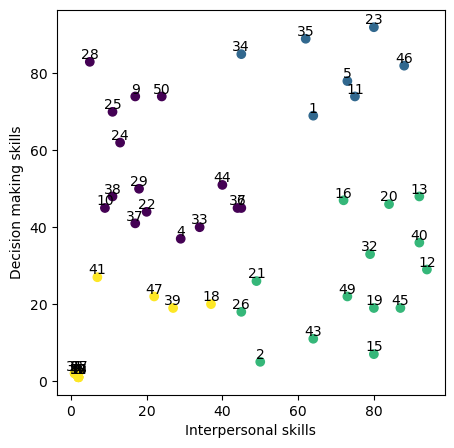

In [14]:
# Plotting Interpersonal skills and Decision making skills and putting the beneficiary ID labels on it

plt.figure(figsize =(5,5))
plt.scatter(data['Interpersonal skills'], data['Decision making skills'], c=data['groups'])


for i, beneficiary_id in enumerate(data['Beneficiary_ID']):
    plt.text(data['Interpersonal skills'][i], data['Decision making skills'][i], beneficiary_id, ha='center', va='bottom')

plt.xlabel('Interpersonal skills')
plt.ylabel('Decision making skills')


plt.show()

# Conclusion

Based on the K-means algorithm, we have identified four clusters consisting of beneficiaries with similar levels of variance and performance in decision making and interpersonal skills. It is recommended that the project allocates these beneficiaries into the respective groups for more focused follow-up and dedicated support, utilizing tailored project activities.